In [21]:
import pandas as pd
import matplotlib.pyplot as plt

In [22]:
filtered = pd.read_csv('bobcat_163_True_Active.csv')
unfiltered = pd.read_csv('bobcat_163_False_Active.csv')
# FILTERING BY PEOPLE WITH SUBJECT ID = 155 - 665 train, 214 valid, 215 test
# Parse comma-separated IDs
filtered['q_ids'] = filtered['sampled_q_ids'].str.split(',')
filtered['subj_ids'] = filtered['sampled_subject_ids'].str.split(',')
unfiltered['q_ids'] = unfiltered['sampled_q_ids'].str.split(',')
unfiltered['subj_ids'] = unfiltered['sampled_subject_ids'].str.split(',')

In [23]:
filtered.head()

,user_id,sampled_q_ids,sampled_subject_ids,student_total_questions,q_ids,subj_ids
0,3507,"0,2,3,4,6,10,11,14,18,19","189,3,156,155,56,148,202,156,137,156,3",531,"[0, 2, 3, 4, 6, 10, 11, 14, 18, 19]","[189, 3, 156, 155, 56, 148, 202, 156, 137, 156..."
1,5784,"0,2,3,4,6,11,12,13,14,18","189,3,156,155,56,148,156,284,44,137,156",490,"[0, 2, 3, 4, 6, 11, 12, 13, 14, 18]","[189, 3, 156, 155, 56, 148, 156, 284, 44, 137,..."
2,5424,"0,2,3,4,6,10,11,12,14,18","189,3,156,155,56,148,202,156,284,137,156",535,"[0, 2, 3, 4, 6, 10, 11, 12, 14, 18]","[189, 3, 156, 155, 56, 148, 202, 156, 284, 137..."
3,5481,"0,2,3,6,10,11,14,18,19,22","189,3,156,155,148,202,156,137,156,3,189",553,"[0, 2, 3, 6, 10, 11, 14, 18, 19, 22]","[189, 3, 156, 155, 148, 202, 156, 137, 156, 3,..."
4,4511,"0,2,3,6,10,11,14,17,18,19","189,3,156,155,148,202,156,137,60,156,3",612,"[0, 2, 3, 6, 10, 11, 14, 17, 18, 19]","[189, 3, 156, 155, 148, 202, 156, 137, 60, 156..."


In [24]:
unfiltered.head()

,user_id,sampled_q_ids,sampled_subject_ids,student_total_questions,q_ids,subj_ids
0,3507,"736,852,547,300,740,118,526,233,492,170","155,156,155,153,36,114,63,3,127,39",531,"[736, 852, 547, 300, 740, 118, 526, 233, 492, ...","[155, 156, 155, 153, 36, 114, 63, 3, 127, 39]"
1,5784,"736,852,264,547,626,300,740,898,790,261","155,156,220,155,164,153,36,39,148,153",490,"[736, 852, 264, 547, 626, 300, 740, 898, 790, ...","[155, 156, 220, 155, 164, 153, 36, 39, 148, 153]"
2,5424,"736,852,300,898,261,502,880,596,790,370","155,156,153,39,153,36,146,3,148,195",535,"[736, 852, 300, 898, 261, 502, 880, 596, 790, ...","[155, 156, 153, 39, 153, 36, 146, 3, 148, 195]"
3,5481,"736,852,547,300,740,898,790,261,502,880","155,156,155,153,36,39,148,153,36,146",553,"[736, 852, 547, 300, 740, 898, 790, 261, 502, ...","[155, 156, 155, 153, 36, 39, 148, 153, 36, 146]"
4,4511,"736,852,300,740,898,626,261,502,596,370","155,156,153,36,39,164,153,36,3,195",612,"[736, 852, 300, 740, 898, 626, 261, 502, 596, ...","[155, 156, 153, 36, 39, 164, 153, 36, 3, 195]"


In [32]:
all_subj_filtered = [s for subj_list in filtered['subj_ids'] for s in subj_list]
all_subj_unfiltered = [s for subj_list in unfiltered['subj_ids'] for s in subj_list]

subj_counts_f = pd.Series(all_subj_filtered).value_counts()
subj_counts_u = pd.Series(all_subj_unfiltered).value_counts()

comparison = pd.DataFrame({
    'Filtered': subj_counts_f,
    'Unfiltered': subj_counts_u
}).fillna(0).astype(int)
comparison['Difference'] = abs(comparison['Filtered'] - comparison['Unfiltered'])
comparison2 = comparison.sort_values('Difference', ascending=False)
print(comparison.head(20))
print("="*40)
print(comparison2.head(20))

     Filtered  Unfiltered  Difference
114         0          75          75
117         0           9           9
126         0          10          10
127         0          29          29
128         0          12          12
129         0           6           6
135         0           5           5
137       110           2         108
146         0          72          72
148       206         138          68
153         6         244         238
155       196         313         117
156       476         187         289
163        14          18           4
164        41          43           2
165         6           7           1
168         1           0           1
169         1           3           2
170         0           1           1
172         0           4           4
     Filtered  Unfiltered  Difference
156       476         187         289
189       246           0         246
153         6         244         238
36          0         236         236
44        19

In [33]:
# 2. Per-student overlap
overlaps = []
for _, f_row in filtered.iterrows():
    u_row = unfiltered[unfiltered['user_id'] == f_row['user_id']]
    if not u_row.empty:
        u_row = u_row.iloc[0]
        
        q_f = set(f_row['q_ids'])
        q_u = set(u_row['q_ids'])
        s_f = set(f_row['subj_ids'])
        s_u = set(u_row['subj_ids'])
        
        overlaps.append({
            'user_id': f_row['user_id'],
            'q_overlap': len(q_f & q_u),
            'q_overlap_pct': len(q_f & q_u) / len(q_f) * 100,
            's_overlap': len(s_f & s_u),
            's_overlap_pct': len(s_f & s_u) / len(s_f) * 100
        })

overlap_df = pd.DataFrame(overlaps)

print(f"Average Question Overlap: {overlap_df['q_overlap_pct'].mean():.1f}%")
print(f"Average Subject Overlap: {overlap_df['s_overlap_pct'].mean():.1f}%")
print(f"\nStudents analyzed: {len(overlap_df)}")


Average Question Overlap: 0.2%
Average Subject Overlap: 37.0%

Students analyzed: 202


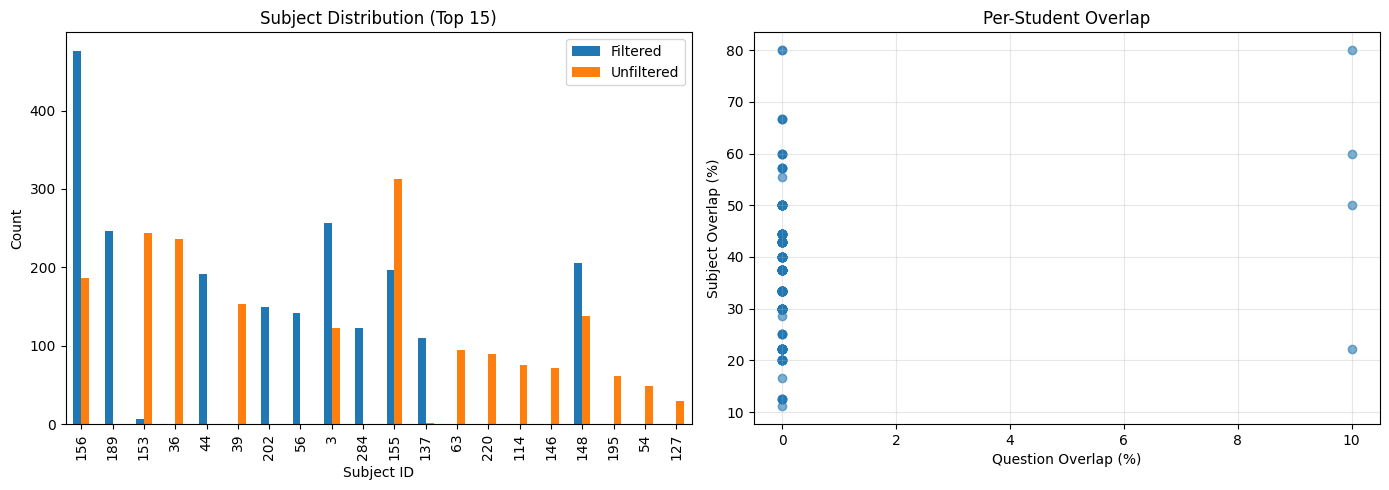

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Subject distribution
top_subjects = comparison2.head(20)
top_subjects[['Filtered', 'Unfiltered']].plot(kind='bar', ax=axes[0])
axes[0].set_title('Subject Distribution (Top 15)')
axes[0].set_xlabel('Subject ID')
axes[0].set_ylabel('Count')
axes[0].legend(['Filtered', 'Unfiltered'])

# Overlap scatter
axes[1].scatter(overlap_df['q_overlap_pct'], overlap_df['s_overlap_pct'], alpha=0.6)
axes[1].set_xlabel('Question Overlap (%)')
axes[1].set_ylabel('Subject Overlap (%)')
axes[1].set_title('Per-Student Overlap')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

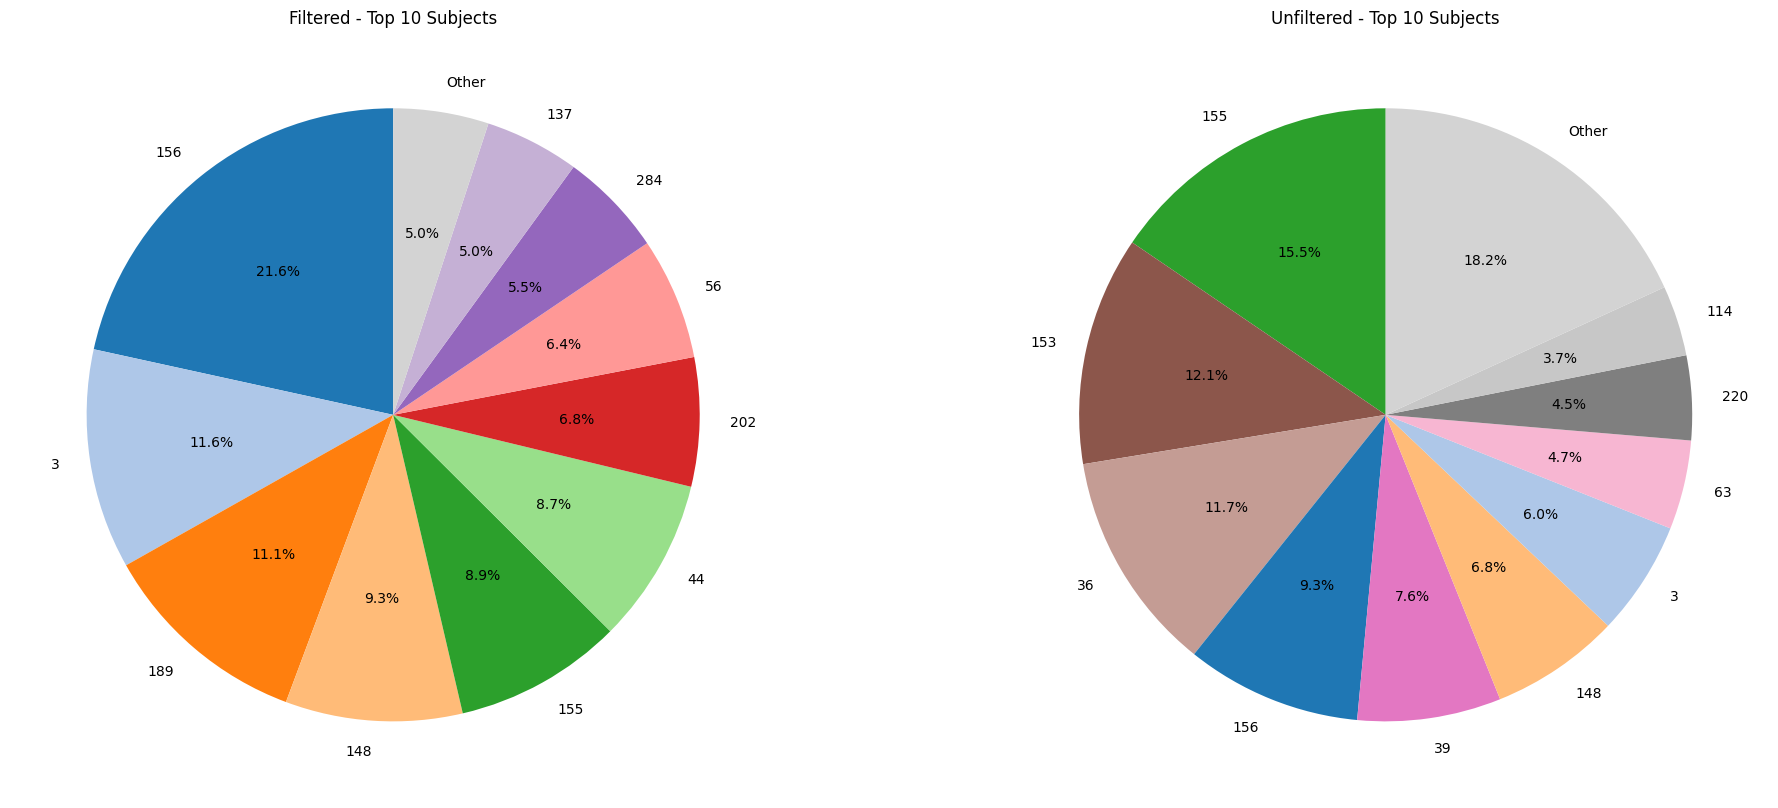

In [28]:
fig = plt.figure(figsize=(20, 16))
top_n = 10

# Get all unique subjects from both datasets and create color map
all_top_subjects = pd.concat([subj_counts_f.head(top_n), subj_counts_u.head(top_n)]).index.unique()
colors = plt.cm.tab20(range(len(all_top_subjects)))
color_map = {subj: colors[i] for i, subj in enumerate(all_top_subjects)}
color_map['Other'] = 'lightgray'

# Filtered pie
ax3 = plt.subplot(2, 2, 3)
top_filtered = subj_counts_f.head(top_n)
other_filtered = subj_counts_f.iloc[top_n:].sum()
pie_filtered = pd.concat([top_filtered, pd.Series({'Other': other_filtered})])
filtered_colors = [color_map.get(subj, 'gray') for subj in pie_filtered.index]
ax3.pie(pie_filtered, labels=pie_filtered.index, autopct='%1.1f%%', startangle=90, colors=filtered_colors)
ax3.set_title(f'Filtered - Top {top_n} Subjects')

# Unfiltered pie
ax4 = plt.subplot(2, 2, 4)
top_unfiltered = subj_counts_u.head(top_n)
other_unfiltered = subj_counts_u.iloc[top_n:].sum()
pie_unfiltered = pd.concat([top_unfiltered, pd.Series({'Other': other_unfiltered})])
unfiltered_colors = [color_map.get(subj, 'gray') for subj in pie_unfiltered.index]
ax4.pie(pie_unfiltered, labels=pie_unfiltered.index, autopct='%1.1f%%', startangle=90, colors=unfiltered_colors)
ax4.set_title(f'Unfiltered - Top {top_n} Subjects')

plt.tight_layout()
plt.show()

In [29]:
unfiltered["num_subjects"] = unfiltered["sampled_subject_ids"].str.split(",").apply(set).apply(len)
filtered["num_subjects"] = filtered["sampled_subject_ids"].str.split(",").apply(set).apply(len)

(0.0, 1.0)

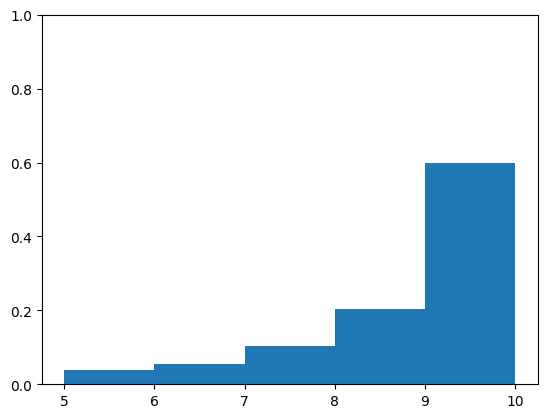

In [30]:
plt.hist(filtered["num_subjects"], density = True, bins=range(5,11))
plt.ylim([0,1])

(0.0, 1.0)

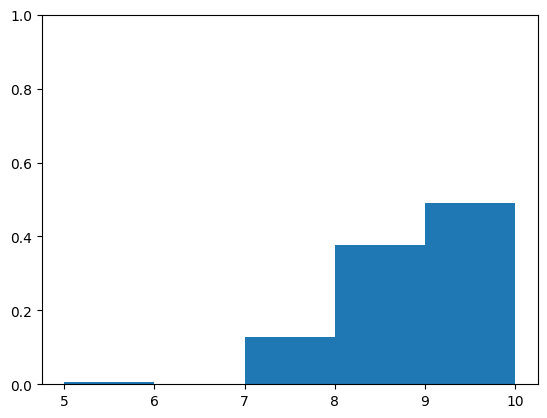

In [31]:
plt.hist(unfiltered["num_subjects"], density = True, bins=range(5,11))
plt.ylim([0,1])